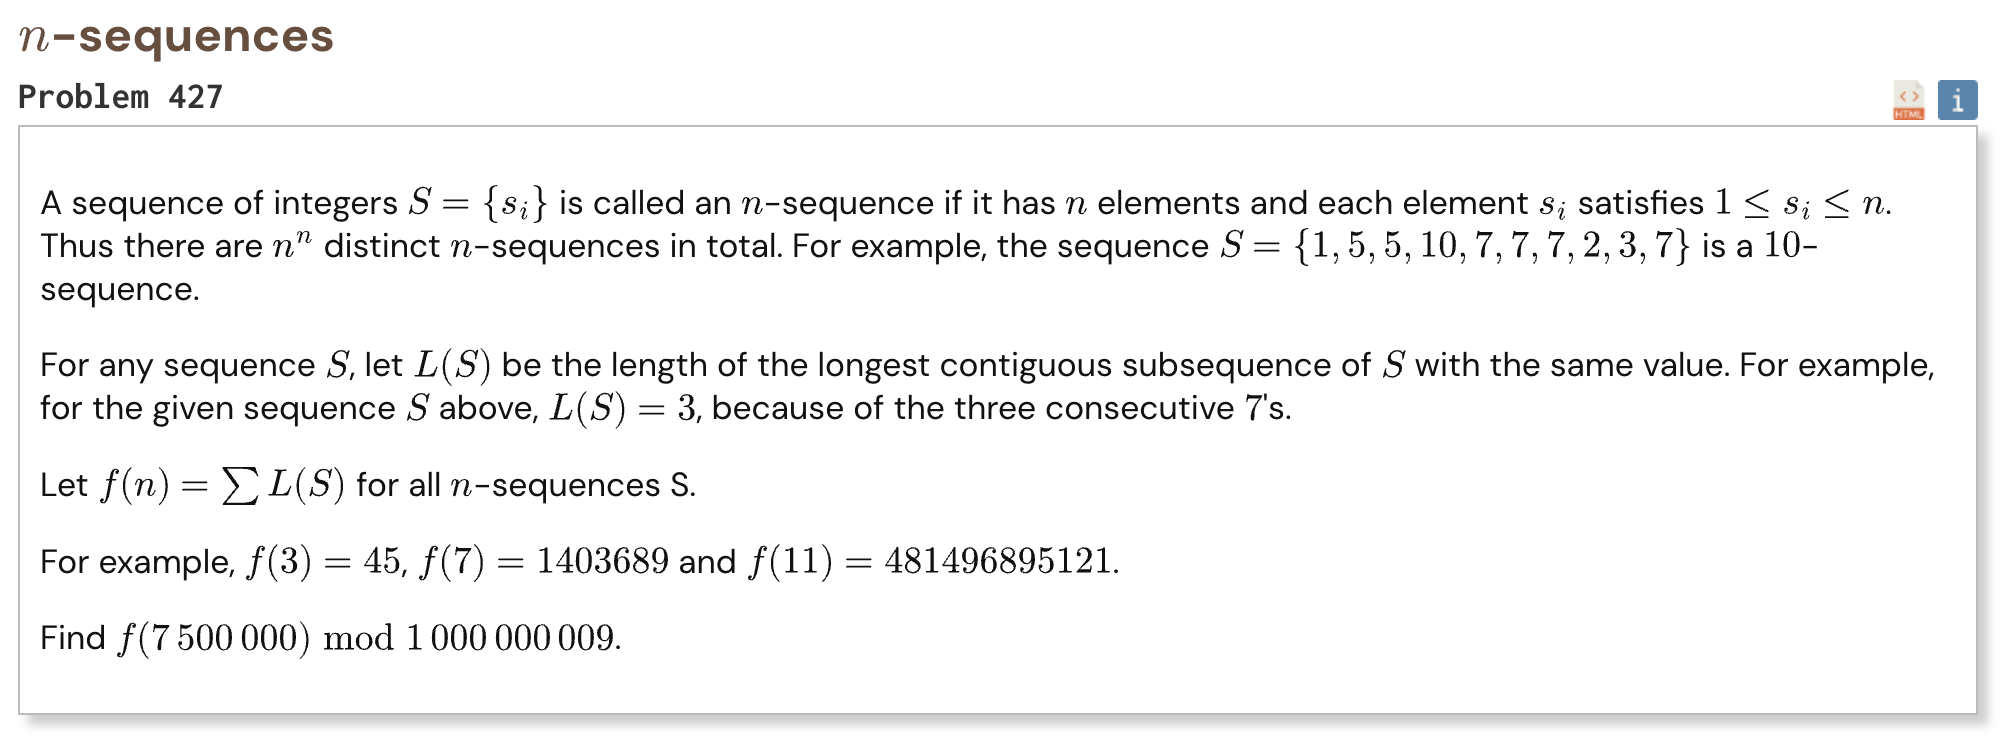

## Initial approach

-   count sequences whose longest equal run is at most a chosen length
-   describe each sequence as consecutive runs where neighbouring runs use different values
-   use a generating function to count all allowed run length combinations
-   expand the generating function with inclusion exclusion to get a direct coefficient formula
-   precompute factorials and inverse factorials so binomial coefficients are fast
-   calculate the count for every possible maximum run length and subtract them from the total contribution
-   work modulo one billion and nine throughout because the final answer only needs that remainder

In [1]:
MOD = 1_000_000_009


def solve(n):
    factorial = [1] * (n + 1)

    for i in range(1, n + 1):
        factorial[i] = factorial[i - 1] * i % MOD

    inverse_factorial = [1] * (n + 1)
    inverse_factorial[n] = pow(factorial[n], MOD - 2, MOD)

    for i in range(n, 0, -1):
        inverse_factorial[i - 1] = inverse_factorial[i] * i % MOD

    def combination(a, b):
        if b < 0 or b > a:
            return 0

        return (
            factorial[a]
            * inverse_factorial[b]
            % MOD
            * inverse_factorial[a - b]
            % MOD
        )

    powers_n = [1] * (n + 1)
    powers_negative = [1] * (n + 1)

    negative = (1 - n) % MOD

    for i in range(1, n + 1):
        powers_n[i] = powers_n[i - 1] * n % MOD
        powers_negative[i] = powers_negative[i - 1] * negative % MOD

    def coefficient(m, k):
        if m < 0:
            return 0

        total = 0
        p = 0

        while p * (k + 1) <= m:
            top = m - p * k
            power_index = m - p * (k + 1)

            term = combination(top, p)
            term = term * powers_n[power_index] % MOD
            term = term * powers_negative[p] % MOD

            total = (total + term) % MOD
            p += 1

        return total

    bounded_total = 0

    for k in range(1, n):
        a = coefficient(n - 1, k)
        b = coefficient(n - 1 - k, k)

        count = n * (a - b) % MOD
        bounded_total = (bounded_total + count) % MOD

    result = (
        pow(n, n + 1, MOD)
        - bounded_total
    ) % MOD

    return result

```python
%%time

result = solve(7_500_000)
print("Result:", result)
```

takes too long to run, needs an optimization.